# Modul 7 — Machine Learning Supervised, Klasifikasi (CRISP-DM Penuh)
## Convergeni Data Consulting (CDC) — Klien: Bank Arta Nusantara

Notebook ini menjalankan seluruh pipeline klasifikasi gagal_bayar Modul 7: data
sintetis Jalur D, class imbalance, LogisticRegression dengan dan tanpa
class_weight, confusion matrix, ROC-AUC, PR-AUC, dan threshold tuning berbasis
biaya bisnis. Setiap angka dan gambar di bawah adalah hasil eksekusi nyata.

## Data Sintetis Jalur D

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
n = 800

pendapatan_juta = np.clip(np.random.normal(14, 6, n), 4, 60)
usia = np.clip(np.random.normal(37, 9, n), 21, 65).round().astype(int)
skor_kredit = np.clip(0.7 * pendapatan_juta + np.random.normal(55, 10, n), 20, 100)
jumlah_tanggungan = np.clip(np.random.poisson(1.8, n), 0, 6)
rasio_cicilan_pendapatan = np.clip(np.random.normal(0.32, 0.12, n), 0.05, 0.9)
jenis_kredit = np.random.choice(["KPR", "UMKM"], size=n, p=[0.55, 0.45])

logit = (
    -3.2 - 0.05 * (skor_kredit - 60) + 4.5 * (rasio_cicilan_pendapatan - 0.3)
    + 0.18 * jumlah_tanggungan - 0.01 * (usia - 37)
    + np.where(jenis_kredit == "UMKM", 0.4, 0.0)
)
prob_gagal = 1 / (1 + np.exp(-logit))
gagal_bayar = np.random.binomial(1, prob_gagal)

df = pd.DataFrame({
    "pendapatan_juta": pendapatan_juta.round(2), "usia": usia,
    "skor_kredit": skor_kredit.round(1), "jumlah_tanggungan": jumlah_tanggungan,
    "rasio_cicilan_pendapatan": rasio_cicilan_pendapatan.round(3),
    "jenis_kredit": jenis_kredit, "gagal_bayar": gagal_bayar,
})
print(df["gagal_bayar"].value_counts())
print(f"Proporsi gagal bayar: {df['gagal_bayar'].mean():.4f}")

gagal_bayar
0    757
1     43
Name: count, dtype: int64
Proporsi gagal bayar: 0.0537


## Split dan Pipeline (Default vs class_weight=balanced)

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, average_precision_score

fitur_numerik = ["pendapatan_juta", "usia", "skor_kredit", "jumlah_tanggungan", "rasio_cicilan_pendapatan"]
fitur_kategorikal = ["jenis_kredit"]
X = df[fitur_numerik + fitur_kategorikal]
y = df["gagal_bayar"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), fitur_numerik),
    ("cat", OneHotEncoder(drop="first"), fitur_kategorikal),
])

pipeline = Pipeline([("preprocessor", preprocessor), ("model", LogisticRegression(max_iter=1000))])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

pipeline_seimbang = Pipeline([("preprocessor", preprocessor), ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))])
pipeline_seimbang.fit(X_train, y_train)
y_pred_seimbang = pipeline_seimbang.predict(X_test)
y_proba_seimbang = pipeline_seimbang.predict_proba(X_test)[:, 1]

print("Tanpa class_weight:")
print(confusion_matrix(y_test, y_pred))
print("\nDengan class_weight='balanced':")
print(confusion_matrix(y_test, y_pred_seimbang))

Tanpa class_weight:
[[189   0]
 [ 11   0]]

Dengan class_weight='balanced':
[[124  65]
 [  5   6]]


## Visualisasi: Confusion Matrix Berdampingan (Asset Baru)

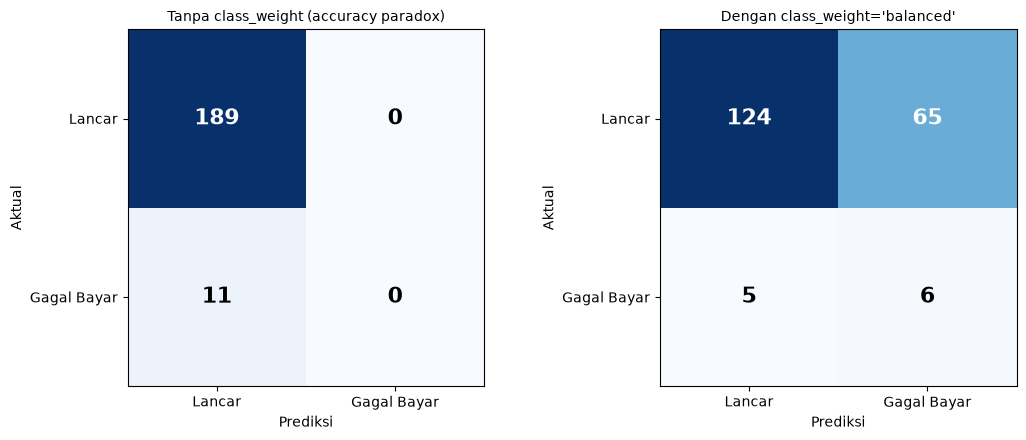

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, pred, judul in zip(axes, [y_pred, y_pred_seimbang], ["Tanpa class_weight (accuracy paradox)", "Dengan class_weight='balanced'"]):
    cm = confusion_matrix(y_test, pred)
    im = ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=16, fontweight="bold")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Lancar", "Gagal Bayar"]); ax.set_yticklabels(["Lancar", "Gagal Bayar"])
    ax.set_xlabel("Prediksi"); ax.set_ylabel("Aktual")
    ax.set_title(judul, fontsize=10)
plt.tight_layout()
plt.savefig("modul07_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Visualisasi: Kurva ROC (Asset Baru)

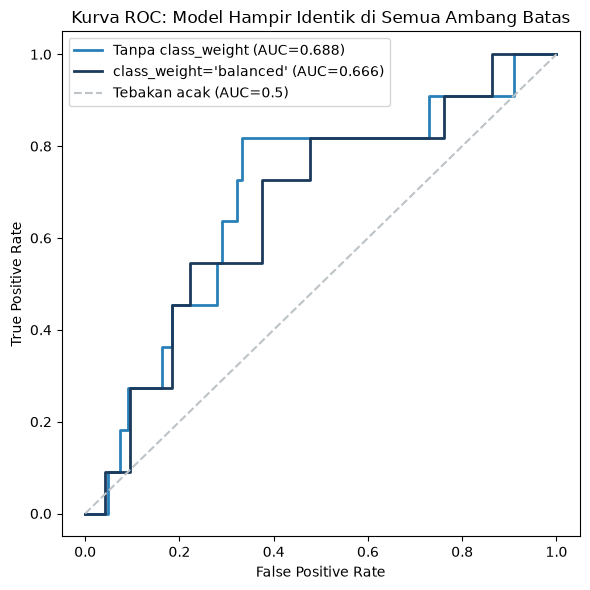

In [4]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
fpr_b, tpr_b, _ = roc_curve(y_test, y_proba_seimbang)
auc_default = roc_auc_score(y_test, y_proba)
auc_balanced = roc_auc_score(y_test, y_proba_seimbang)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color="#2980B9", linewidth=2, label=f"Tanpa class_weight (AUC={auc_default:.3f})")
ax.plot(fpr_b, tpr_b, color="#1B3A5C", linewidth=2, label=f"class_weight='balanced' (AUC={auc_balanced:.3f})")
ax.plot([0, 1], [0, 1], color="#BDC3C7", linestyle="--", label="Tebakan acak (AUC=0.5)")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Kurva ROC: Model Hampir Identik di Semua Ambang Batas")
ax.legend()
plt.tight_layout()
plt.savefig("modul07_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## Threshold Tuning Berbasis Biaya

In [5]:
BIAYA_FN = 150
BIAYA_FP = 15

hasil_threshold = []
for thresh in np.arange(0.05, 0.96, 0.05):
    pred = (y_proba_seimbang >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    biaya_total = fn * BIAYA_FN + fp * BIAYA_FP
    hasil_threshold.append({"threshold": round(thresh, 2), "FP": fp, "FN": fn, "biaya_juta": biaya_total})

hasil_threshold = pd.DataFrame(hasil_threshold)
print(hasil_threshold.to_string(index=False))
threshold_optimal = hasil_threshold.loc[hasil_threshold["biaya_juta"].idxmin()]
print("\nOptimal:")
print(threshold_optimal)

 threshold  FP  FN  biaya_juta
      0.05 189   0        2835
      0.10 189   0        2835
      0.15 185   0        2775
      0.20 180   0        2700
      0.25 165   0        2475
      0.30 151   1        2415
      0.35 125   2        2175
      0.40 104   2        1860
      0.45  90   3        1800
      0.50  65   5        1725
      0.55  50   5        1500
      0.60  38   6        1470
      0.65  26   8        1590
      0.70  16  10        1740
      0.75   8  10        1620
      0.80   2  11        1680
      0.85   0  11        1650
      0.90   0  11        1650
      0.95   0  11        1650

Optimal:
threshold        0.6
FP              38.0
FN               6.0
biaya_juta    1470.0
Name: 11, dtype: float64


## Visualisasi: Kurva Biaya vs Ambang Batas (Asset Baru — Data Nyata untuk M07-02)

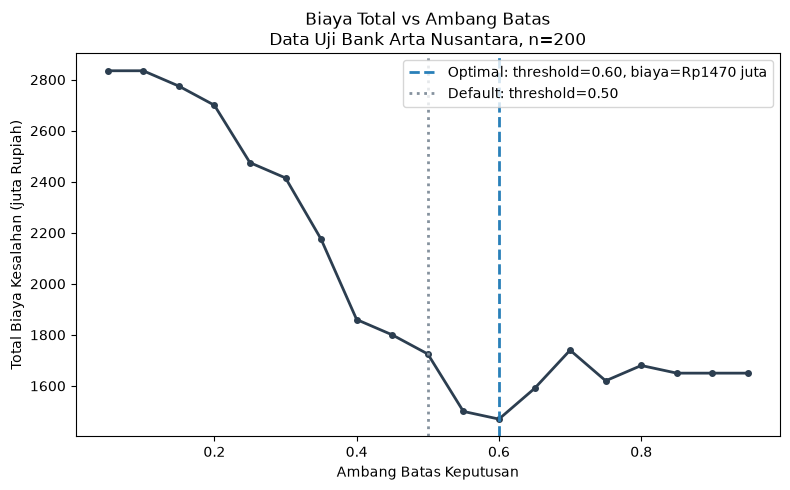

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(hasil_threshold["threshold"], hasil_threshold["biaya_juta"], color="#2C3E50", linewidth=2, marker="o", markersize=4)
opt_row = threshold_optimal
ax.axvline(opt_row["threshold"], color="#2980B9", linestyle="--", linewidth=2,
            label=f"Optimal: threshold={opt_row['threshold']:.2f}, biaya=Rp{opt_row['biaya_juta']:.0f} juta")
ax.axvline(0.50, color="#85929E", linestyle=":", linewidth=2, label="Default: threshold=0.50")
ax.set_xlabel("Ambang Batas Keputusan")
ax.set_ylabel("Total Biaya Kesalahan (juta Rupiah)")
ax.set_title("Biaya Total vs Ambang Batas\nData Uji Bank Arta Nusantara, n=200")
ax.legend()
plt.tight_layout()
plt.savefig("modul07_threshold_cost.png", dpi=150, bbox_inches="tight")
plt.show()